# Visualization Exercises Part 5

This is the fifth of several exercise pages on visualization using [Matplotlib](http://matplotlib.org/index.html) that were prepared for use in the course ITSE 1302 at Austin Community College.

The remainder of this exercise page will concentrate on **box and whisker** plots. Before continuing, it is recommended that you read [Box Plot: Display of Distribution](http://www.physics.csbsju.edu/stats/box2.html) to confirm that you have an overall understanding of box and whisker plots. 

Pay particular attention to the statement that reads "This simplest possible box plot displays the full range of variation (from min to max), the likely range of variation (the IQR), and a typical value (the median)." on the webpage referenced above.

It is also recommended that you read [Notched Box Plots](https://datavizcatalogue.com/blog/chart-snapshot-notched-box-plots/) to confirm that you have an understanding of that aspect of the topic as well. According to that reference:
"The height of the notches is proportional to the interquartile range (IQR) of the sample and inversely proportional to the square root of the sample size. This relationship means that larger notches indicate greater variability in the data or smaller sample sizes.

The purpose of the notches is to help visually compare medians between different groups. If the notches of the two box plots do not overlap, it provides evidence that the medians of the two groups are statistically significantly different at the 5% significance level.

In other words, a Notched Box Plot more clearly displays the statistical significance of the difference between medians, compared to a regular Box Plot. This makes Notched Box Plots particularly useful when you want to quickly assess whether medians are meaningfully different across groups or conditions."

## Import required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from statistics import mean
from statistics import median
from statistics import stdev
import math

## Utility methods

### Normal probabilty density function

Define a function from which you can obtain values for the normal probability density curve for any input values of mu and sigma. See [Engineering Statistics Handbook](http://www.itl.nist.gov/div898/handbook/eda/section3/eda3661.htm) for a definition of the equation for the normal probability density function.

In [2]:
'''
Computes and return values for the normal probabilty density function

required input: x-axis value
optional input: mu
optional input: sigma

returns: The computed value of the function for the given x, mu, and sigma. If mu and sigma are not provided as
input arguments, the method reverts to returning values for the standard normal distribution curve with mu = 0
and sigma = 1.0
'''
def normalProbabilityDensity(x,mu=0,sigma=1.0):
    
    eVal = 2.718281828459045
    exp = -((x-mu)**2)/(2*(sigma**2))
    numerator = pow(eVal,exp)
    denominator = sigma*(math.sqrt(2*math.pi))
    return numerator/denominator

### A random dataset generator

Define a utility function that returns a dataset of more or less normally distributed values. The returned dataset is uniformly distributed for an input keyword argument value of **numberSamples=1**. The resulting dataset tends more towards normal as the value of numberSamples is increased.

In [3]:
def normalRandomGenerator(seed=1,dataLength=10000,numberSamples=50,lowLim=0,highLim=100):
    '''
    Create a new dataset of dataLength values consisting of the average of numberSamples 
    samples taken from a population of uniformly distributed values between lowLim 
    and highLim generated with a seed of seed.

    Input keyword argument and their default values:

    seed = 1 seed used to generate the uniformly distributed values
    dataLength = 10000 number of samples in the returned list of values
    numberSamples = 50 number of samples taken from the uniformly distributed population
                       and averaged into the output
    lowLim = 0 lower limit value of the uniformly distributed population
    highLim = 100 high limit value of the uniformly distributed population

    returns: a list containing the dataset

    '''
    data = []
    random.seed(seed)

    for cnt in range(dataLength):
        theSum = 0
        for cnt1 in range(numberSamples):
            theSum += random.uniform(lowLim,highLim)
        data.append(theSum/numberSamples)
        
    return data

### Fancy plotHistAndBox function

This method is more powerful than a function with the same name that was defined on an earlier exercise page. This version incorporates some but not all of the keyword arguments of the [Axes.boxplot](http://matplotlib.org/2.0.2/api/_as_gen/matplotlib.axes.Axes.boxplot.html?highlight=boxplot#matplotlib.axes.Axes.boxplot) method that support different variations of the plot.

Define a function that Plots a histogram and a "box and whisker" plot for an incoming dataset on a 1x2 row of an incoming figure specified by axes. The row index on which to plot the data is specified by axesRow. Also creates and plots a normal prpobability density curve on the histogram based on the mean and standard deviation of the dataset. Set **multiDim** to True if axes is in a multi-dimensional array.

Set the supported keyword arguments described for the [Axes.boxplot](http://matplotlib.org/2.0.2/api/_as_gen/matplotlib.axes.Axes.boxplot.html?highlight=boxplot#matplotlib.axes.Axes.boxplot) method to create different variations of the plot.

In [4]:
'''
Plots a histogram and a "box and whisker" plot for 
an incoming dataset on a 1x2 row of an incoming figure
specified by axes. The row index on which to plot the 
data is specified by axesRow. Also creates and plots
a normal prpobability density curve on the histogram 
based on the mean and standard deviation of the 
dataset. Set multiDim to true if axes is in a 
multi-dimensional array.
'''

def plotHistAndBox(data,axes,axesRow=0,multiDim=False,
                   showmeans=None,
                   meanline=None,
                   showbox=None, 
                   showcaps=None,
                   notch=None, 
                   bootstrap=None,
                   showfliers=None,
                   sym=None,
                   boxprops=None,
                   flierprops=None, 
                   medianprops=None, 
                   meanprops=None, 
                   capprops=None, 
                   whiskerprops=None
                  ):

    dataBar = mean(data)
    dataStd = stdev(data)

    if multiDim == True:
        #Plot and label histogram
        dataN,dataBins,dataPat = axes[axesRow,0].hist(
            data,bins=136,density=True)
        axes[axesRow,0].set_title('data')
        axes[axesRow,0].set_xlabel('x')
        axes[axesRow,0].set_ylabel('Relative Freq')

        #Plot a boxplot
        axes[axesRow,1].boxplot(data,vert=False,widths=0.75,
                               showmeans=showmeans,
                               meanline=meanline,
                               showbox=showbox, 
                               showcaps=showcaps,
                               notch=notch, 
                               bootstrap=bootstrap,
                               showfliers=showfliers,
                               sym=sym,
                               boxprops=boxprops,
                               flierprops=flierprops, 
                               medianprops=medianprops, 
                               meanprops=meanprops, 
                               capprops=capprops, 
                               whiskerprops=whiskerprops
                               )
        axes[axesRow,1].set_title('Box and Whisker Plot')
        axes[axesRow,1].set_xlabel('x')
        
    else:
        #Plot and label histogram
        dataN,dataBins,dataPat = axes[0].hist(
            data,bins=136,density=True,range=(min(data),max(data)))
        axes[0].set_title('data')
        axes[0].set_xlabel('x')
        axes[0].set_ylabel('Relative Freq')

        #Plot a boxplot
        axes[1].boxplot(data,vert=False,widths=0.75,
                       showmeans=showmeans,
                       meanline=meanline,
                       showbox=showbox, 
                       showcaps=showcaps,
                       notch=notch, 
                       bootstrap=bootstrap,
                       showfliers=showfliers,
                       sym=sym,
                       boxprops=boxprops,
                       flierprops=flierprops, 
                       medianprops=medianprops, 
                       meanprops=meanprops, 
                       capprops=capprops, 
                       whiskerprops=whiskerprops
                       )
        axes[1].set_title('Box and Whisker Plot')
        axes[1].set_xlabel('x')

    #Compute the values for a normal probability density curve for the 
    # data mu and sigma across the same range of values.
    x = np.arange(dataBins[0],dataBins[len(dataBins)-1],0.1)
    y = [normalProbabilityDensity(
        val,mu=dataBar,sigma=dataStd) for val in x]

    #Superimpose the normal probability density curve on the histogram.
    if multiDim == True:
        axes[axesRow,0].plot(x,y,label='normal probability density')
    else:
        axes[0].plot(x,y,label='normal probability density')

## Basic box and whisker plot

The [Axes.boxplot](http://matplotlib.org/2.0.2/api/_as_gen/matplotlib.axes.Axes.boxplot.html?highlight=boxplot#matplotlib.axes.Axes.boxplot) method supports a large number of keyword arguments that can be used to produce different variations of the plot. We will begin by creating box plots for three different distributions of data using the default arguments for the method.

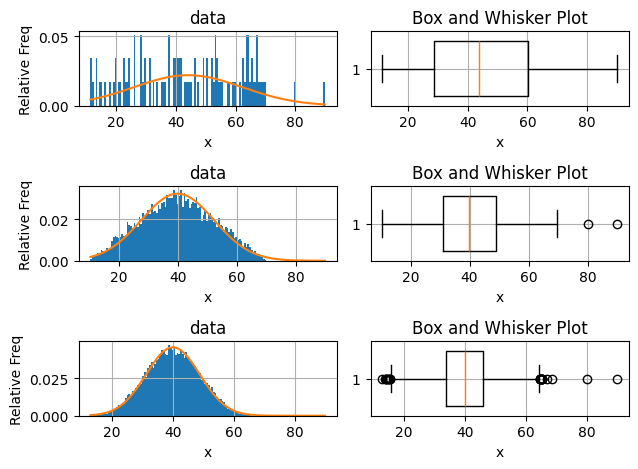

In [5]:
#Create three datasets with different spreads and with outliers.
g01 = normalRandomGenerator(dataLength=99,numberSamples=1,
                            lowLim=10,highLim=70,seed=2) + [68.5] + [80] + [90]
g02 = normalRandomGenerator(dataLength=9999,numberSamples=2,
                            lowLim=10,highLim=70,seed=2) + [68.5] + [80] + [90]
g03 = normalRandomGenerator(dataLength=9999,numberSamples=4,
                            lowLim=10,highLim=70,seed=2) + [68.5] + [80] + [90]

#Create a figure with three rows and two columns
fig,axes = plt.subplots(3,2)

#Call the plotHistAndBox function to process the first dataset
plotHistAndBox(g01,axes,axesRow=0,multiDim=True)

#Process the second dataset
plotHistAndBox(g02,axes,axesRow=1,multiDim=True)
               
#Process the third dataset
plotHistAndBox(g03,axes,axesRow=2,multiDim=True)


axes[0,0].grid(True)
axes[0,1].grid(True)
axes[1,0].grid(True)
axes[1,1].grid(True)
axes[2,0].grid(True)
axes[2,1].grid(True)

fig.tight_layout()
plt.savefig("VisualizationPart05.zzz.png")
plt.show()

## **Description of the image shown above, VisualizationPart05.01.png**

### Type of Image
This figure is a three‑row, two‑column arrangement of plots in which each row contains a histogram on the left and a box‑and‑whisker plot on the right. The histograms display distributions of data values, and the box‑and‑whisker plots summarize the same datasets using quartiles, whiskers, and outlier markers.

Side note: A box‑and‑whisker plot is a graphical summary of a dataset based on its quartiles. The box spans the interquartile range, which contains the middle 50 percent of the data. A line inside the box marks the median. Whiskers extend outward from the box to show the range of values that fall within 1.5 times the interquartile range. Any data points beyond the whiskers are plotted individually as outliers. This type of plot makes it easy to compare the center, spread, and unusual values across different datasets.

### Overall Summary
The image compares three datasets that differ in spread and sample size but share the same outlier values. Each row shows how the distribution appears as a histogram and how the same distribution is represented as a box‑and‑whisker plot. As the datasets become larger and smoother, the histograms more closely resemble a normal distribution, while the box‑and‑whisker plots reveal increasing numbers of outliers and changes in the interquartile range.

### Detailed Description
The figure contains three horizontal pairs of plots. In each pair, the left plot is a histogram labeled with “Relative Freq” on the vertical axis and “x” on the horizontal axis. An orange curve overlays each histogram, indicating an approximate normal density function. The right plot in each pair is a box‑and‑whisker plot labeled “Box and Whisker Plot” with an x‑axis labeled “x.”

In the top row, the histogram shows a relatively irregular distribution due to the smaller sample size. The bars vary in height without forming a smooth or clearly defined peak. The corresponding box‑and‑whisker plot displays a moderately wide interquartile range, with whiskers extending to the smallest and largest non‑outlier values. No individual outlier markers appear in this plot, indicating that all data points fall within the whisker limits.

In the middle row, the histogram is smoother and more symmetric, reflecting the larger dataset. The box‑and‑whisker plot shows a narrower interquartile range and a clearer separation between the main body of the data and the outliers. Two outliers are shown on the high end.

In the bottom row, the histogram is very smooth and closely resembles a normal distribution. The box‑and‑whisker plot shows a tight interquartile range and multiple outliers on both the low and high ends, making the extreme values more prominent relative to the main distribution.

All six plots include grid lines, and the overall layout is arranged in a 3x2 grid.

### Purpose of the Image
The purpose of this image is to demonstrate how the Axes.boxplot method represents datasets with different spreads and sample sizes using its default settings. The figure illustrates how histograms and box‑and‑whisker plots complement each other when analyzing distribution shape, variability, and outliers across multiple datasets.


The orange vertical lines in each of the three box plots shown above represents the median for the distribution. The right and left edges of the box represent the first and third quartiles. The width of the box represents the IQR or interquartile range. The vertical lines at the ends of the whiskers represent the limits beyond which values are considered to be outliers or fliers in matplotlib terminology.

The top plot shown above was created for data with a uniform distribution. The standard deviation for this data was so large that none of the values were considered to be outliers.

The middle plot was created for data with a more normal distribution and approximately half the variance or a reduction in the standard deviation of approximately 1.414. In this case, the two circles on the right represent outliers. 

The bottom plot was created for data with another reduction in standard deviation of approximately 1.414. Eight to ten values were considered to be outliers in this case. Because the circles overlap, it is not possible to count the exact number of outliers.

## Show outliers (fliers) with a different symbol

The [Axes.boxplot](http://matplotlib.org/2.0.2/api/_as_gen/matplotlib.axes.Axes.boxplot.html?highlight=boxplot#matplotlib.axes.Axes.boxplot) method refers to outliers as fliers. 

You can change the symbol used to show outliers with the **sym** keyword. This is illustrated by the following code.

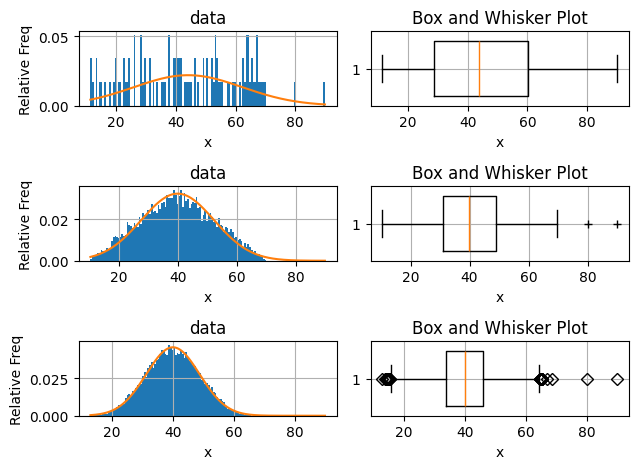

In [6]:
#Create three datasets with different spreads and with outliers.
g01 = normalRandomGenerator(dataLength=99,numberSamples=1,
                            lowLim=10,highLim=70,seed=2) + [68.5] + [80] + [90]
g02 = normalRandomGenerator(dataLength=9999,numberSamples=2,
                            lowLim=10,highLim=70,seed=2) + [68.5] + [80] + [90]
g03 = normalRandomGenerator(dataLength=9999,numberSamples=4,
                            lowLim=10,highLim=70,seed=2) + [68.5] + [80] + [90]

#Create a figure with three rows and two columns
fig,axes = plt.subplots(3,2)

#Call the plotHistAndBox function to process the first dataset
plotHistAndBox(g01,axes,axesRow=0,multiDim=True)

#Process the second dataset
plotHistAndBox(g02,axes,axesRow=1,multiDim=True,sym='+')
               
#Process the third dataset
plotHistAndBox(g03,axes,axesRow=2,multiDim=True,sym='D')


axes[0,0].grid(True)
axes[0,1].grid(True)
axes[1,0].grid(True)
axes[1,1].grid(True)
axes[2,0].grid(True)
axes[2,1].grid(True)

fig.tight_layout()
plt.savefig("VisualizationPart05.zzz.png")
plt.show()

## **Description of the image shown above, VisualizationPart05.02.png**

### Type of Image
This figure is a three‑row, two‑column arrangement of histograms and box‑and‑whisker plots. Each row shows a histogram on the left and a corresponding box‑and‑whisker plot on the right, using the same datasets as in the previous example.

### Overall Summary
The image illustrates how the symbol used to mark outliers in a box‑and‑whisker plot can be changed with the sym keyword in the Axes.boxplot method. The three rows display histogram‑and‑box‑plot pairs that are identical to the previous image except for the marker style used to represent outliers.

### Detailed Description
Each row contains a histogram labeled with “Relative Freq” on the vertical axis and “x” on the horizontal axis, along with an overlaid smooth curve. To the right of each histogram is a box‑and‑whisker plot summarizing the same dataset. The first row uses the default outlier marker but there are no outliers in that row. In the second row, the outliers are drawn using plus signs (+), and in the third row the outliers are drawn using diamond‑shaped markers. The distributions and quartile structures match those in the earlier figure; only the outlier symbols differ.

### Purpose of the Image
The purpose of this image is to demonstrate how to modify the appearance of outliers, referred to as fliers in the Axes.boxplot method, by supplying a different symbol through the sym keyword. This allows customization of outlier markers while preserving the underlying statistical representation.

This is the same data as in the previous example. There are no outliers in the top box plot shown above. The symbol for outliers in the middle box plot is set to '+'. The symbol for outliers in the bottom box plot is set to 'D' for diamond.

## Show the mean value and hide the box

The following code illustrates the effect of the **showmeans**, **meanline**, and **showbox** arguments.

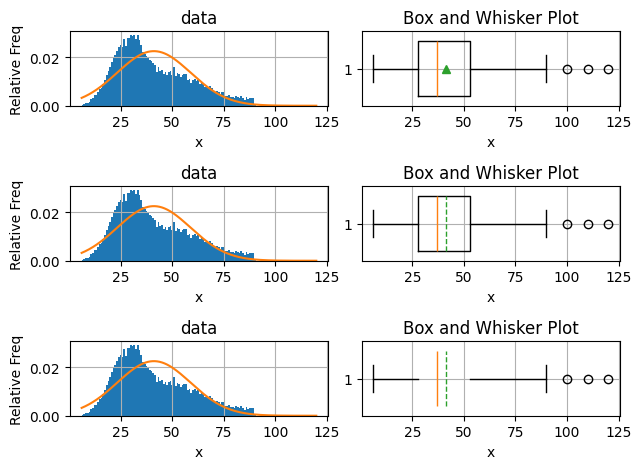

In [7]:
#Create a skewed dataset with outliers.
g01 = normalRandomGenerator(dataLength=10000,
                            numberSamples=3,lowLim=5,highLim=50,seed=1)
g02 = normalRandomGenerator(dataLength=7000,
                            numberSamples=2,lowLim=20,highLim=80,seed=2)
g03 = normalRandomGenerator(dataLength=4000,
                            numberSamples=1,lowLim=30,highLim=90,seed=3)

g04 = g01 + g02 + g03 +[100] + [110] + [120]

#Create a figure with three rows and two columns
fig,axes = plt.subplots(3,2)

plotHistAndBox(g04,axes,axesRow=0,multiDim=True,
               showmeans=True)

plotHistAndBox(g04,axes,axesRow=1,multiDim=True,
               showmeans=True,meanline=True)

plotHistAndBox(g04,axes,axesRow=2,multiDim=True,
               showmeans=True,meanline=True,showbox=False)

axes[0,0].grid(True)
axes[0,1].grid(True)
axes[1,0].grid(True)
axes[1,1].grid(True)
axes[2,0].grid(True)
axes[2,1].grid(True)

plt.tight_layout()
plt.savefig("VisualizationPart05.zzz.png")
plt.show()

## **Description of the image shown above, VisualizationPart05.03.png**

### Type of Image
This figure is a three‑row, two‑column arrangement of plots. Each row contains a histogram on the left and a box‑and‑whisker plot on the right. All three rows use the same skewed dataset with outliers, but the box‑and‑whisker plots differ in how the mean and box elements are displayed based on the showmeans, meanline, and showbox arguments.

### Overall Summary
The image demonstrates how different display options in the Axes.boxplot method affect the visual presentation of the mean and the box element. The histograms remain identical across all rows, while the box‑and‑whisker plots show three variations: mean shown as a point, mean shown as a line, and mean shown as a line with the box hidden. This allows comparison of how these options influence the interpretation of the distribution.

### Detailed Description
Each row begins with a histogram labeled with “Relative Freq” on the vertical axis and “x” on the horizontal axis. The histograms show a skewed distribution with a long right tail and several extreme values. A smooth curve overlays each histogram to indicate the approximate shape of a normal distribution. This comparison indicates that the distributions are far from normal.

To the right of each histogram is a box‑and‑whisker plot summarizing the same dataset. In the first row, the box‑and‑whisker plot displays the interquartile range, whiskers, and outliers, and the mean is shown as a distinct green triangular marker inside the box. In the second row, the mean is shown as a dashed green vertical line instead of a point, while the box and whiskers remain visible. In the third row, the mean is again shown as a dashed green vertical line, but the box is hidden entirely, leaving only the whiskers, outliers, median, and mean indicators. Across all three rows, the whiskers extend to the non‑outlier limits, and the outliers appear as individual empty circles beyond the whiskers.

### Purpose of the Image
The purpose of this image is to illustrate how the showmeans, meanline, and showbox arguments modify the appearance of a box‑and‑whisker plot. These options allow the user to display the mean as a point or a line and to hide the box element when desired. The figure demonstrates how these settings change the visual emphasis of the plot while preserving the underlying statistical information conveyed by the whiskers and outliers.

The top plot shown above sets the **showmeans** argument to True and shows the mean value as a green triangle.

The middle plot sets the **showmeans** and **meanline** arguments to True. This causes the program to display the mean value as a green dashed line.

The bottom plot sets the **showbox** argument to False without changing the other two arguments. This causes the program to display the mean value as a green dashed line and hides the surrounding box.

## The showcaps, showfliers, and notch arguments

The following code illustrates the effect of the **showcaps**, **showfliers**, and **notch** arguments.

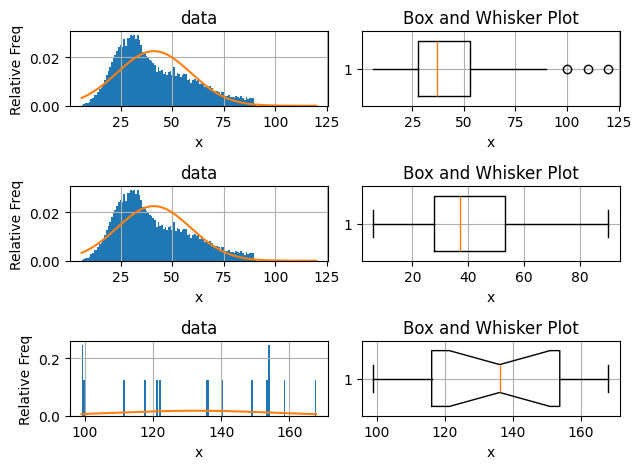

In [8]:
#Create a skewed dataset with outliers.
g01 = normalRandomGenerator(dataLength=10000,
                            numberSamples=3,lowLim=5,highLim=50,seed=1)
g02 = normalRandomGenerator(dataLength=7000,
                            numberSamples=2,lowLim=20,highLim=80,seed=2)
g03 = normalRandomGenerator(dataLength=4000,
                            numberSamples=1,lowLim=30,highLim=90,seed=3)

g04 = g01 + g02 + g03 +[100] + [110] + [120]

#Create a figure with three rows and two columns
fig,axes = plt.subplots(3,2)

plotHistAndBox(g04,axes,axesRow=0,multiDim=True,
               showcaps=False)

plotHistAndBox(g04,axes,axesRow=1,multiDim=True,
               showfliers=False)

#Create a dataset that will illustrate a notch.
g05=[99.2,99.0,100.0,111.6,122.2,117.6,121.1,136.0,
154.2,153.6,158.5,140.6,136.2,168.0,154.3,149.0]

#Process the dataset for the notch.
plotHistAndBox(g05,axes,axesRow=2,multiDim=True,notch=True)

axes[0,0].grid(True)
axes[0,1].grid(True)
axes[1,0].grid(True)
axes[1,1].grid(True)
axes[2,0].grid(True)
axes[2,1].grid(True)

plt.tight_layout()
plt.savefig("VisualizationPart05.zzz.png")
plt.show()

## **Description of the image shown above, VisualizationPart05.04.png**

### Type of Image
This figure is a three‑row, two‑column arrangement of plots. Each row contains a histogram on the left and a box‑and‑whisker plot on the right. The figure demonstrates how the showcaps, showfliers, and notch arguments in the Axes.boxplot method affect the appearance of box‑and‑whisker plots when applied to skewed datasets with outliers.

### Overall Summary
The image compares three variations of box‑and‑whisker plots generated from two different datasets. The first two rows use the same skewed dataset with outliers but differ in whether the caps or fliers are displayed. The third row uses a separate dataset to illustrate the appearance of a notched box. The histograms in each row show the underlying distributions, while the box‑and‑whisker plots highlight how specific display options modify the visual representation of quartiles, whiskers, caps, and outliers.

### Detailed Description
Each row begins with a histogram labeled with “Relative Freq” on the vertical axis and “x” on the horizontal axis. The histograms for the first two rows show a right‑skewed distribution with a long tail and several extreme values. A smooth curve overlays each histogram to indicate the approximate shape of a normal distribution. The histogram in the third row displays a smaller dataset with values concentrated in a higher range, producing a more irregular pattern of bars.

To the right of each histogram is a box‑and‑whisker plot summarizing the corresponding dataset. In the first row, the showcaps argument is set to False, so the whiskers extend from the box without the short horizontal cap lines normally drawn at their ends. Outliers appear as individual points beyond the whiskers. In the second row, the showfliers argument is set to False, so the box‑and‑whisker plot displays the quartiles and whiskers but omits the individual outlier markers. In the third row, the notch argument is set to True, producing a notched box shape that narrows around the median. The whiskers extend to the non‑outlier limits, and no outliers appear as individual points beyond the whiskers. The notched box visually emphasizes the median and provides a way to compare medians across groups when multiple notched plots are shown together.

### Purpose of the Image
The purpose of this image is to illustrate how the showcaps, showfliers, and notch arguments modify the appearance of box‑and‑whisker plots. These options allow the user to hide the cap lines, suppress the display of outliers, or introduce a notch around the median. The figure demonstrates how these settings change the visual emphasis of the plot while preserving the underlying statistical information conveyed by the quartiles and whiskers.

The top plot sets the value of **showcaps** to False causing the caps (the short vertical lines) on the ends of whiskers to disappear.

The middle plot sets the value of **showfliers** to False causing the outliers (fliers) to disappear. This in turn causes the horizontal scale to be modified such that the whiskers occupy almost the entire width of the plot.

The bottom plot creates a dataset that illustrates a notch and sets the value of **notch** to True producing a box with a notch.

## Cosmetics

In addition to the essential properties of the box and whisker plot discussed above, it is also possible to set a number of other properties that are more in the nature of cosmetics. These properties are controlled by the following keyword arguments:

- boxprops
- flierprops 
- medianprops 
- meanprops 
- capprops 
- whiskerprops

Each of these arguments is a dictionary that contains specifications for one or more properties of the portion of the plot to which the argument applies.


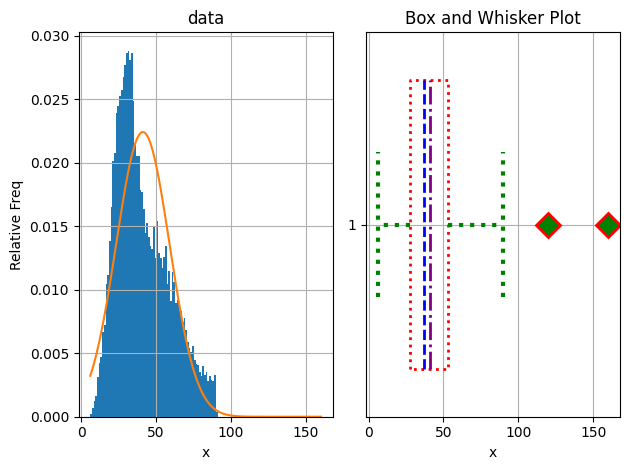

In [9]:
#Create a skewed dataset with outliers.
g01 = normalRandomGenerator(dataLength=10000,
                            numberSamples=3,lowLim=5,highLim=50,seed=1)
g02 = normalRandomGenerator(dataLength=7000,
                            numberSamples=2,lowLim=20,highLim=80,seed=2)
g03 = normalRandomGenerator(dataLength=4000,
                            numberSamples=1,lowLim=30,highLim=90,seed=3)

g04 = g01 + g02 + g03 +[120] + [160]

#Create a figure with one row and two columns.
fig,axes = plt.subplots(1,2)

#Create dictionaries containing specifications for 
# various cosmetic properties.
myBoxProps = dict(linestyle=':',linewidth=2,color='red')

myFlierProps = dict(marker='D',markerfacecolor='green',
                    markeredgecolor='red',
                    markeredgewidth=2,
                    markersize=12,linestyle='none')

myMedianProps = dict(linestyle='--',linewidth=2,color='blue')

myMeanProps = dict(linestyle='-.',linewidth=2,color='purple')

myCapProps = dict(linestyle=':',linewidth=3,color='green')

myWhiskerProps = dict(linestyle=':',linewidth=3,color='green')

#Apply the cosmetic properties.
plotHistAndBox(g04,axes,
               boxprops = myBoxProps,
               flierprops=myFlierProps,
               medianprops=myMedianProps,
               showmeans=True,
               meanline=True,
               meanprops=myMeanProps,
               capprops=myCapProps,
               whiskerprops=myWhiskerProps
              )

axes[0].grid(True)
axes[1].grid(True)

plt.tight_layout()
plt.savefig("VisualizationPart05.zzz.png")
plt.show()

## **Description of the image shown above, VisualizationPart05.05.png**

### Type of Image
This figure is a one‑row, two‑column arrangement of plots. The left plot is a histogram showing the distribution of a skewed dataset with outliers, and the right plot is a box‑and‑whisker plot of the same data. The box‑and‑whisker plot uses customized cosmetic properties supplied through the boxprops, flierprops, medianprops, meanprops, capprops, and whiskerprops keyword arguments.

### Overall Summary
The image demonstrates how cosmetic properties can be applied to different components of a box‑and‑whisker plot. The histogram provides a view of the underlying distribution, while the box‑and‑whisker plot shows how line styles, marker styles, colors, and widths can be modified for the box, whiskers, caps, median, mean, and outliers. The figure highlights how these cosmetic adjustments change the visual appearance without altering the statistical meaning of the plot.

### Detailed Description
The histogram on the left is labeled with “Relative Freq” on the vertical axis and “x” on the horizontal axis. It displays a right‑skewed distribution with most values concentrated in the lower range and a long tail extending toward higher values. A smooth curve overlays the histogram to show the approximate shape of a normal distribution.

The box‑and‑whisker plot on the right summarizes the same dataset. The box is drawn using red dotted lines with increased line width. The median is shown as a blue dashed line inside the box. The mean is displayed as a purple dash‑dot line because the showmeans and meanline options are enabled. The whiskers and caps are drawn using green dotted lines with increased line width. Outliers appear as large diamond‑shaped markers with green faces, red edges, and no connecting line, reflecting the custom flier properties. The whiskers extend to the non‑outlier limits, and the outliers appear to the right of the whiskers at higher x‑values.

### Purpose of the Image
The purpose of this image is to illustrate how cosmetic properties can be applied to individual components of a box‑and‑whisker plot using the boxprops, flierprops, medianprops, meanprops, capprops, and whiskerprops keyword arguments. These options allow the user to customize the appearance of the plot while preserving the underlying statistical information conveyed by the quartiles, whiskers, and outliers.

The box properties are set to produce a red dotted line with a width of 2'

The outlier or flier properties are set to produce rather large green diamond markers with a red border.

The median properties are set to produce a blue dashed line with a width of 2.

The mean properties are set to produce a purple dash-dot line with a width of 2.

The whisker properties and the cap properties are set to produce a green dotted line with a width of 3.

##### --To be continued in the tutorial titled Visualization Exercises Part 6--

Author: Prof. Richard G. Baldwin, Austin Community College, Austin, TX

File: VisualizationPart05.ipynb

Revised: 03/15/26

Copyright 2018 Richard G. Baldwin

-end-
